In [1]:
import pandas as pd

# Load transcript file (parquet is fastest)
tx = pd.read_parquet("/Volumes/jamboree/spatial/20250725__090712__Tuany_mSkinMelanoma5k_run1/output-XETG00045__0059976__cre_24h__20250725__091031/transcripts.parquet")
print(tx.head())

# Expected columns (10x Xenium standard):
# ['x_location', 'y_location', 'feature_name', 'qv']

     transcript_id     cell_id  overlaps_nucleus feature_name  x_location  \
0  281651070373175  UNASSIGNED                 0       Abcb1a  194.093750   
1  281651070371338  UNASSIGNED                 0         Agr3  198.343750   
2  281651070372380  UNASSIGNED                 0       Angpt1  195.156250   
3  281651070373076  UNASSIGNED                 0        Casp9  196.546875   
4  281651070371145  UNASSIGNED                 0        Cdh20  209.281250   

    y_location  z_location     qv fov_name  nucleus_distance  codeword_index  \
0  2160.593750   20.406250  21.25       R5        642.031250           13443   
1  2155.531250   18.718750  22.75       R5        648.093750            1670   
2  2172.375000   18.765625  22.50       R5        631.046875           18624   
3  2156.968750   18.328125  27.75       R5        646.203125            3061   
4  2160.609375   10.671875  21.75       R5        646.453125           10565   

  codeword_category  is_gene  
0  predesigned_gene     T

In [40]:
import numpy as np

# Define grid size (µm)
GRID_SIZE = 30  # try 30–100 depending on tissue scale

# Assign integer bin coordinates
tx["x_bin"] = (tx["x_location"] // GRID_SIZE).astype(int)
tx["y_bin"] = (tx["y_location"] // GRID_SIZE).astype(int)

# Create a unique spatial bin ID
tx["bin_id"] = tx["x_bin"].astype(str) + "_" + tx["y_bin"].astype(str)

In [41]:
# Count transcripts per gene per bin
expr = (
    tx.groupby(["bin_id", "feature_name"])
      .size()
      .unstack(fill_value=0)
)

# Extract bin coordinates
bin_coords = (
    tx.groupby("bin_id")[["x_bin", "y_bin"]]
      .first()
      .reset_index()
      .set_index("bin_id")
)

In [42]:
import scanpy as sc
import numpy as np

ad = sc.AnnData(X=expr.values)
ad.var_names = expr.columns
ad.obs_names = expr.index
ad.obs[["x_bin", "y_bin"]] = bin_coords.loc[expr.index]
ad.obsm["spatial"] = ad.obs[["x_bin", "y_bin"]].values * GRID_SIZE

In [43]:
sc.pp.calculate_qc_metrics(ad, percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(ad,min_counts=30)
sc.pp.filter_cells(ad,min_genes=10)

In [44]:
ad.layers['counts'] = ad.X.copy()

In [45]:
sc.pp.normalize_total(ad, inplace=True,target_sum=100)
sc.pp.log1p(ad)

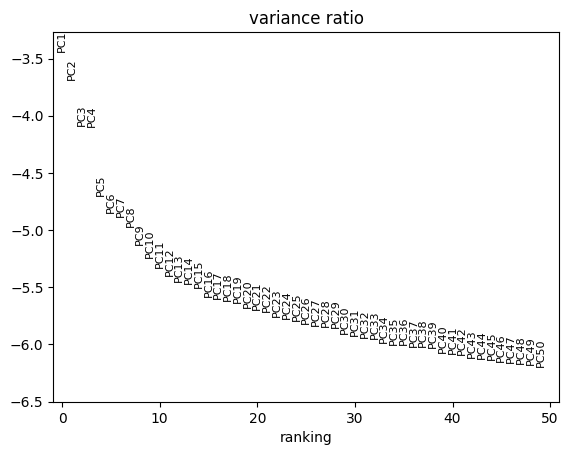

In [46]:
plt.rcdefaults()
sc.tl.pca(ad)
sc.pl.pca_variance_ratio(ad, n_pcs=50, log=True)
sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)

In [47]:
sc.tl.umap(ad, min_dist=0.1)

clustering at resolution 0.5


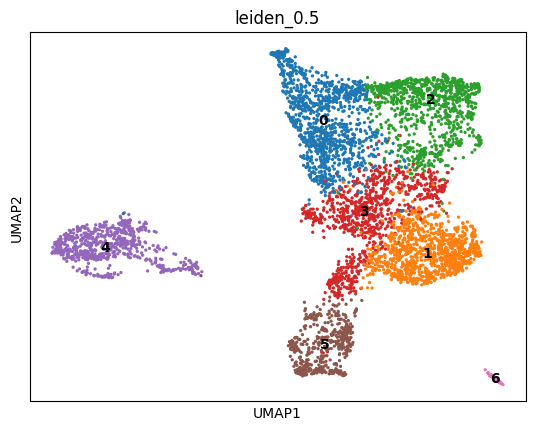

done
clustering at resolution 1


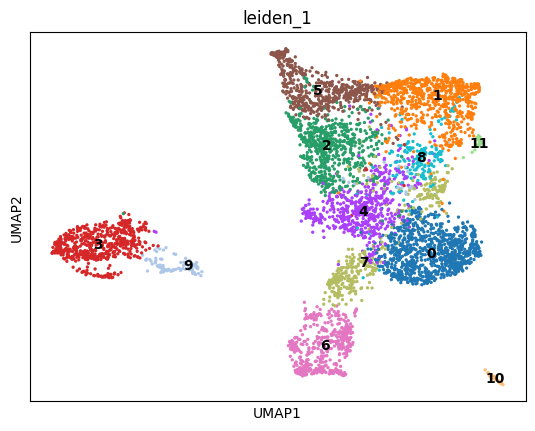

done


In [48]:
resolutions = [0.5, 1]
for resolution in resolutions: 
    print('clustering at resolution '+str(resolution))
    sc.tl.leiden(ad, resolution = resolution, key_added = 'leiden_'+str(resolution))
    sc.pl.umap(ad, color = 'leiden_'+str(resolution), legend_loc = 'on data')
    print("done")

In [49]:
import matplotlib.pyplot as plt

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_52919/3622566354.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad, spot_size=20, color = 'leiden_1')


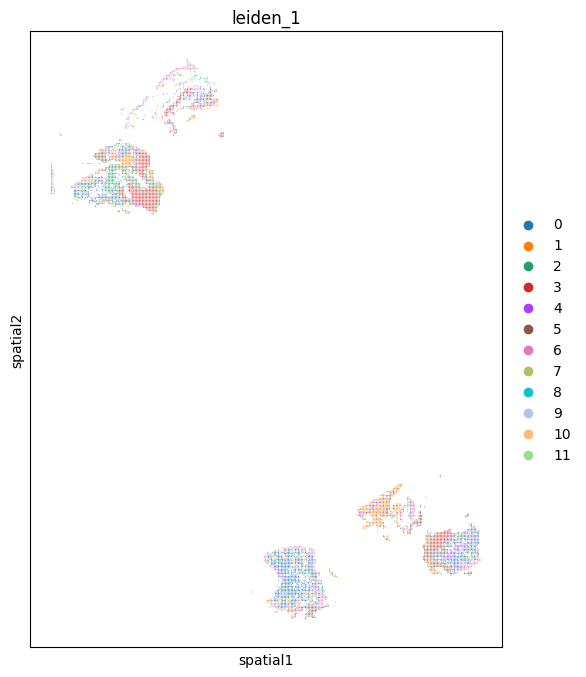

In [50]:
with plt.rc_context({'figure.figsize': (10, 8)}):
        sc.pl.spatial(ad, spot_size=20, color = 'leiden_1')
plt.show()

In [28]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)